In [34]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

In [35]:
df=pd.read_csv('./Cleaned_tele_churn.csv')

In [36]:
df.dtypes

Customer ID                           object
Gender                                object
Age                                    int64
Married                               object
Number of Dependents                   int64
City                                  object
Zip Code                               int64
Latitude                             float64
Longitude                            float64
Number of Referrals                    int64
Tenure in Months                       int64
Offer                                 object
Phone Service                         object
Avg Monthly Long Distance Charges    float64
Multiple Lines                        object
Internet Service                      object
Internet Type                         object
Avg Monthly GB Download              float64
Online Security                       object
Online Backup                         object
Device Protection Plan                object
Premium Tech Support                  object
Streaming 

In [37]:
df['Customer Status'].value_counts()

Stayed     4720
Churned    1869
Joined      454
Name: Customer Status, dtype: int64

In [38]:
df['Customer Status'] = df['Customer Status'].replace('Joined', 'Stayed')

In [39]:
#Converting columns to category
category_columns = ['Gender', 'Married', 'City', 'Offer', 'Phone Service', 'Multiple Lines', 'Internet Service',
                    'Internet Type', 'Online Security', 'Online Backup', 'Device Protection Plan',
                    'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music',
                    'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Customer Status']

df[category_columns] = df[category_columns].astype('category')

## Feature Scaling

In [40]:
category_columns = ['Offer', 'Phone Service', 'Multiple Lines', 'Internet Service',
                    'Internet Type', 'Online Security', 'Online Backup', 'Device Protection Plan',
                    'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music',
                    'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Customer Status']
data = df[category_columns].copy()
encoder = LabelEncoder()
for column in category_columns:
    data.loc[:, column] = encoder.fit_transform(data[column])



In [41]:
df_encoded= pd.DataFrame(data, columns= category_columns)

In [43]:
numeric=['Tenure in Months','Avg Monthly Long Distance Charges','Avg Monthly GB Download','Monthly Charge','Total Charges',
        'Total Refunds','Total Extra Data Charges','Total Long Distance Charges','Total Revenue']

In [44]:
data_num=df[numeric]

scaler = StandardScaler()
scaled_data=scaler.fit_transform(data_num)
df_scaled = pd.DataFrame(scaled_data, columns=numeric)

In [45]:
df_scaled

,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue
0,-0.952994,1.257532e+00,-0.587869,0.064221,-0.744500,-0.248313,-0.273300,-0.434195,-0.718872
1,-0.952994,-1.091613e+00,-0.934015,-2.166367,-0.766962,4.602325,0.125055,-0.771190,-0.846108
2,-1.156740,6.098500e-01,0.219805,0.330225,-0.882382,-0.248313,-0.273300,-0.725844,-0.914111
3,-0.789997,1.778149e-01,-1.280161,1.102599,-0.460063,-0.248313,-0.273300,-0.457641,-0.500827
4,-1.197489,-1.336902e+00,-0.876324,0.650712,-0.888318,-0.248313,-0.273300,-0.858681,-0.958059
...,...,...,...,...,...,...,...,...,...
7038,-0.789997,1.575445e+00,1.892844,-0.270687,-0.678482,-0.248313,-0.273300,-0.168036,-0.588006
7039,-0.423253,-6.832912e-01,-0.530178,0.689171,-0.179466,-0.248313,-0.273300,-0.463855,-0.280726
7040,-1.238238,-5.039558e-01,1.431316,-0.426124,-0.965390,-0.248313,-0.273300,-0.840845,-1.013748
7041,1.410464,-1.726697e+00,1.835153,0.136331,1.035837,-0.248313,-0.273300,-0.717056,0.605693


In [46]:
df_f = pd.concat([df_scaled,df_encoded], axis =1)

In [47]:
df_f

,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Offer,...,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Customer Status
0,-0.952994,1.257532e+00,-0.587869,0.064221,-0.744500,-0.248313,-0.273300,-0.434195,-0.718872,0,...,0,1,1,0,0,1,1,1,1,1
1,-0.952994,-1.091613e+00,-0.934015,-2.166367,-0.766962,4.602325,0.125055,-0.771190,-0.846108,0,...,0,0,0,1,1,0,0,0,1,1
2,-1.156740,6.098500e-01,0.219805,0.330225,-0.882382,-0.248313,-0.273300,-0.725844,-0.914111,5,...,1,0,0,0,0,1,0,1,0,0
3,-0.789997,1.778149e-01,-1.280161,1.102599,-0.460063,-0.248313,-0.273300,-0.457641,-0.500827,4,...,1,0,1,1,0,1,0,1,0,0
4,-1.197489,-1.336902e+00,-0.876324,0.650712,-0.888318,-0.248313,-0.273300,-0.858681,-0.958059,0,...,0,1,1,0,0,1,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,-0.789997,1.575445e+00,1.892844,-0.270687,-0.678482,-0.248313,-0.273300,-0.168036,-0.588006,4,...,0,1,0,0,1,1,1,0,1,1
7039,-0.423253,-6.832912e-01,-0.530178,0.689171,-0.179466,-0.248313,-0.273300,-0.463855,-0.280726,4,...,0,0,0,1,1,1,0,1,0,0
7040,-1.238238,-5.039558e-01,1.431316,-0.426124,-0.965390,-0.248313,-0.273300,-0.840845,-1.013748,5,...,0,0,0,0,0,1,0,1,1,1
7041,1.410464,-1.726697e+00,1.835153,0.136331,1.035837,-0.248313,-0.273300,-0.717056,0.605693,1,...,1,1,0,1,1,1,2,0,1,1


In [55]:
Z = df.iloc[:,:1]
Z

,Customer ID
0,0002-ORFBO
1,0003-MKNFE
2,0004-TLHLJ
3,0011-IGKFF
4,0013-EXCHZ
...,...
7038,9987-LUTYD
7039,9992-RRAMN
7040,9992-UJOEL
7041,9993-LHIEB


In [50]:
final= pd.concat([df_f,Z], axis=1)

In [51]:
final.isnull().values.any()

False

In [56]:
final

,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Offer,...,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Customer Status,Customer ID
0,-0.952994,1.257532e+00,-0.587869,0.064221,-0.744500,-0.248313,-0.273300,-0.434195,-0.718872,0,...,1,1,0,0,1,1,1,1,1,0002-ORFBO
1,-0.952994,-1.091613e+00,-0.934015,-2.166367,-0.766962,4.602325,0.125055,-0.771190,-0.846108,0,...,0,0,1,1,0,0,0,1,1,0003-MKNFE
2,-1.156740,6.098500e-01,0.219805,0.330225,-0.882382,-0.248313,-0.273300,-0.725844,-0.914111,5,...,0,0,0,0,1,0,1,0,0,0004-TLHLJ
3,-0.789997,1.778149e-01,-1.280161,1.102599,-0.460063,-0.248313,-0.273300,-0.457641,-0.500827,4,...,0,1,1,0,1,0,1,0,0,0011-IGKFF
4,-1.197489,-1.336902e+00,-0.876324,0.650712,-0.888318,-0.248313,-0.273300,-0.858681,-0.958059,0,...,1,1,0,0,1,0,1,1,0,0013-EXCHZ
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,-0.789997,1.575445e+00,1.892844,-0.270687,-0.678482,-0.248313,-0.273300,-0.168036,-0.588006,4,...,1,0,0,1,1,1,0,1,1,9987-LUTYD
7039,-0.423253,-6.832912e-01,-0.530178,0.689171,-0.179466,-0.248313,-0.273300,-0.463855,-0.280726,4,...,0,0,1,1,1,0,1,0,0,9992-RRAMN
7040,-1.238238,-5.039558e-01,1.431316,-0.426124,-0.965390,-0.248313,-0.273300,-0.840845,-1.013748,5,...,0,0,0,0,1,0,1,1,1,9992-UJOEL
7041,1.410464,-1.726697e+00,1.835153,0.136331,1.035837,-0.248313,-0.273300,-0.717056,0.605693,1,...,1,0,1,1,1,2,0,1,1,9993-LHIEB


In [58]:
final['Customer Status'].value_counts()

1    5174
0    1869
Name: Customer Status, dtype: int64

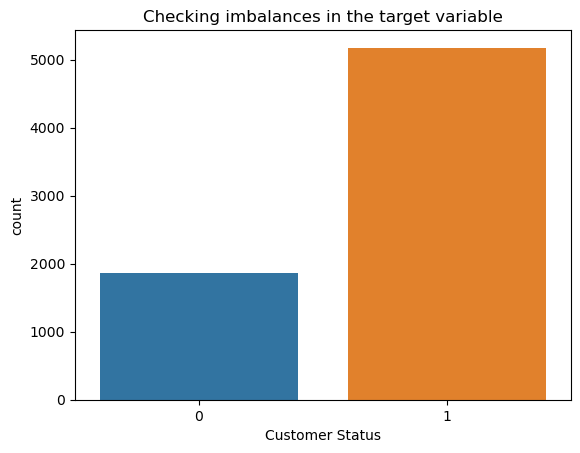

In [59]:
sns.countplot(x='Customer Status', data=final)
plt.title('Checking imbalances in the target variable')
plt.show()

In [60]:
from imblearn.over_sampling import RandomOverSampler

In [61]:
X = final.drop("Customer Status", axis=1)
y = final["Customer Status"]

oversampler = RandomOverSampler()
X_resampled, y_resampled = oversampler.fit_resample(X, y)

In [62]:
df_resampled = pd.concat([X_resampled, y_resampled], axis=1)

In [63]:
df_combined = pd.concat([df_f, df_resampled], axis=0, ignore_index=True)

In [64]:
df_combined['Customer Status'].value_counts()

1    10348
0     7043
Name: Customer Status, dtype: int64

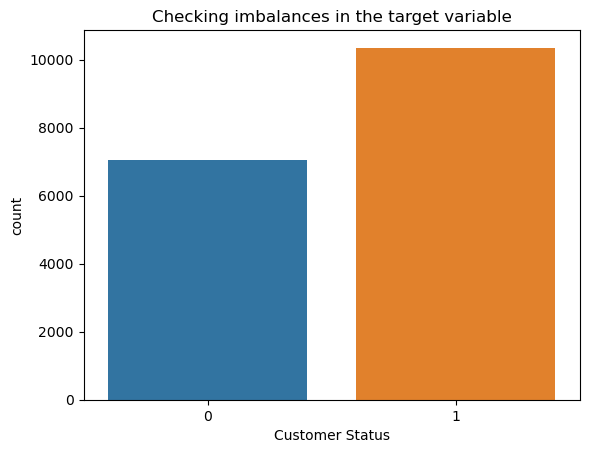

In [65]:
sns.countplot(x='Customer Status', data=df_combined)
plt.title('Checking imbalances in the target variable')
plt.show()

In [66]:
df_combined.to_csv('churn_final.csv', index=False)